# Machine Learning Basics
## Homework 2 : Optimization
Amirali Dehghani - 810102443

### Question 5: Genetic Algorithm - Jigsaw Puzzle Solver

1.  **Library Imports:**
    * We import `numpy` for efficient matrix operations and vector calculations.
    * `matplotlib` is used for visualization.
    * `skimage` and `PIL` are used to load the standard "Astronaut" test image and handle color space conversions.

2.  **Algorithm Configuration:**
    * **`ROWS` & `COLS`**: Set to $4 \times 4$, creating a puzzle with **16 pieces**.
    * **`POP_SIZE`**: Defined as **1000**. A larger population helps maintain genetic diversity.
    * **`MUTATION_RATE`**: Set to **0.5**. This relatively high rate allows the algorithm to explore the search space aggressively and escape local optima.

3.  **Image Processing & Segmentation (Crucial Step):**
    * **Resizing:** The image is resized to ensure its dimensions are perfectly divisible by the number of rows and columns.
    * **CIELAB Color Space:** The image is converted from RGB to **LAB**. Unlike RGB, the Euclidean distance in the LAB color space corresponds closely to human visual perception. This significantly improves the accuracy of edge matching.
    * **Piece Extraction:** The image is sliced into a grid. For every piece, the pixel values of the four borders (**Top, Bottom, Left, Right**) are extracted and stored. These edges will be compared mathematically to solve the puzzle.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image
from skimage import data, color

ROWS, COLS = 4, 4
POP_SIZE = 1000
MUTATION_RATE = 0.5
GENERATIONS = 4000
img_array = data.astronaut()
img = Image.fromarray(img_array)
img = img.convert('RGB')
img = img.resize((COLS * 50, ROWS * 50))
img_rgb = np.array(img)
img_lab = color.rgb2lab(img_rgb)

piece_h = img_lab.shape[0] // ROWS
piece_w = img_lab.shape[1] // COLS
pieces_data = []
display_pieces = []

for r in range(ROWS):
    for c in range(COLS):
        r_s, r_e = r * piece_h, (r+1) * piece_h
        c_s, c_e = c * piece_w, (c+1) * piece_w
        
        sub_lab = img_lab[r_s:r_e, c_s:c_e]
        sub_rgb = img_rgb[r_s:r_e, c_s:c_e]
        
        edges = {
            'top': sub_lab[0, :, :],
            'bottom': sub_lab[-1, :, :],
            'left': sub_lab[:, 0, :],
            'right': sub_lab[-1, :, :]
        }
        pieces_data.append(edges)
        display_pieces.append(sub_rgb)

num_pieces = ROWS * COLS

### Part (a) - Fit Score Definition & Pre-calculation

In this step, we define the mathematical core of the puzzle solver: how to measure if two pieces fit together. Instead of calculating this repeatedly during the genetic evolution (which would be very slow), we **pre-calculate** the compatibility of every possible pair of pieces.

1.  **Edge Distance Function (`calc_edge_dist`):**
    * We mathematically define the "dissimilarity" between two edges using the **Mean Euclidean Distance** in the LAB color space.
    * **Formula:** $\frac{1}{N} \sum \sqrt{(R_i - L_j)^2}$
    * A lower value means the colors along the edge match closely, indicating a good fit.

2.  **Cost Matrices (Lookup Tables):**
    * We create two $N \times N$ matrices, where $N$ is the number of pieces (16):
        * **`diff_LR[i, j]`**: Stores the cost if Piece $i$ is placed to the **Left** of Piece $j$ (comparing $i$'s Right edge vs $j$'s Left edge).
        * **`diff_UD[i, j]`**: Stores the cost if Piece $i$ is placed **Above** Piece $j$ (comparing $i$'s Bottom edge vs $j$'s Top edge).
    * **Efficiency:** By computing these $16 \times 16 = 256$ values once, the fitness function becomes a simple matrix lookup ($O(1)$) rather than a heavy calculation, speeding up the algorithm significantly.

In [2]:
def calc_edge_dist(e1, e2):
    if e1.shape != e2.shape: return 99999
    return np.mean(np.sqrt(np.sum((e1 - e2)**2, axis=1)))

diff_LR = np.zeros((num_pieces, num_pieces))
diff_UD = np.zeros((num_pieces, num_pieces))

for i in range(num_pieces):
    for j in range(num_pieces):
        if i == j: 
            diff_LR[i, j] = float('inf')
            diff_UD[i, j] = float('inf')
            continue
        diff_LR[i, j] = calc_edge_dist(pieces_data[i]['right'], pieces_data[j]['left'])
        diff_UD[i, j] = calc_edge_dist(pieces_data[i]['bottom'], pieces_data[j]['top'])

### Part (b) - Fitness Function

This function evaluates the quality of a specific puzzle arrangement (an individual in the population). The goal is to maximize the fitness score, which corresponds to minimizing the mismatch between adjacent pieces.

1.  **Grid Reconstruction:**
    * The individual, which is a flat list of piece indices (a permutation), is reshaped into a $4 \times 4$ grid to represent the actual puzzle layout.

2.  **Cost Calculation:**
    * We iterate through the grid to sum the "mismatch costs" for all connections:
        * **Horizontal Loop:** For every piece, we check the piece to its immediate right. We look up the cost in `diff_LR`.
        * **Vertical Loop:** For every piece, we check the piece immediately below it. We look up the cost in `diff_UD`.
    * This summation represents the total error in the puzzle assembly.

3.  **Fitness Score:**
    * The genetic algorithm needs a value to *maximize*. Since we have a *cost* (error) that we want to minimize, we inverse it.
    * **Formula:** $Fitness = \frac{100,000}{1 + TotalCost}$
    * The constant $1$ prevents division by zero. The numerator $100,000$ scales the result to a readable range. A perfect puzzle will have a cost of $0$ and a very high fitness score.

In [3]:
def get_fitness(individual):
    cost = 0
    grid = np.array(individual).reshape(ROWS, COLS)
    
    for r in range(ROWS):
        for c in range(COLS - 1):
            cost += diff_LR[grid[r, c], grid[r, c+1]]
            
    for r in range(ROWS - 1):
        for c in range(COLS):
            cost += diff_UD[grid[r, c], grid[r+1, c]]
            
    return 100000 / (1 + cost)

### Part (c) - Selection Mechanism

In this step, we implement the **Tournament Selection** method to choose parents for the next generation. This approach simulates "Survival of the Fittest" while maintaining genetic diversity.

1.  **The Process:**
    * We randomly select a small subset of `k` individuals (contestants) from the entire population.
    * We compare their fitness scores.
    * The individual with the **highest fitness** in this random group is declared the winner and selected as a parent.

2.  **Why Tournament?**
    * It is more efficient than ranking the entire population.
    * **`k=5` (Selection Pressure):** The parameter `k` controls the pressure. A larger `k` favors only the very best (reducing diversity), while a small `k` gives weaker individuals a chance to reproduce (maintaining diversity). We use `k=5` as a balanced choice.

In [4]:
def tournament_selection(population, scores, k=5):
    selected_indices = random.sample(range(len(population)), k)
    best_idx = selected_indices[0]
    for idx in selected_indices:
        if scores[idx][0] > scores[best_idx][0]:
            best_idx = idx
    return scores[best_idx][1]

### Part (d) - Evolutionary Engine & Local Search

This cell contains the core logic that drives the genetic algorithm, combining all previous components into a loop that mimics natural evolution. It also includes a critical enhancement: **Local Search**.

1.  **Genetic Operators:**
    * **`crossover_ox1` (Order Crossover):** Standard crossover methods can produce invalid permutations (duplicates or missing pieces). OX1 solves this by copying a sub-segment from Parent 1 and filling the remaining slots with genes from Parent 2 in the order they appear, ensuring every piece appears exactly once.
    * **`mutate_swap`:** Randomly swaps two pieces in an individual. This introduces small variations to prevent the population from becoming too similar (stagnation).

2.  **Local Search (The Finisher):**
    * Genetic algorithms are excellent at finding a "good neighborhood" of solutions but can struggle to find the *precise* peak.
    * **Logic:** The `local_search` function takes the best solution found by evolution and systematically swaps every pair of pieces. If a swap improves the fitness, it keeps the change. This "polishing" step ensures that small, final errors (like two swapped sky pieces) are corrected.

3.  **`run_evolution` (The Main Loop):**
    * **Initialization:** Starts with a random population.
    * **Elitism:** The top 2 best individuals are automatically copied to the next generation to ensure we never lose the best solution found so far.
    * **Selection & Breeding:** Parents are chosen from the top 30% of the population. They produce offspring via crossover (80% probability) or cloning (20%), followed by mutation.
    * **Termination:** The loop runs for a fixed number of generations or until a perfect score is reached. Finally, `local_search` is applied to the best result to guarantee a clean solution.

In [5]:
def crossover_ox1(p1, p2):
    start, end = sorted(random.sample(range(len(p1)), 2))
    child = [-1] * len(p1)
    child[start:end] = p1[start:end]
    ptr = 0
    for x in p2:
        if x not in child:
            while child[ptr] != -1: ptr += 1
            child[ptr] = x
    return child

def mutate_swap(child, rate):
    if random.random() < rate:
        for _ in range(random.randint(1, 2)): 
            i, j = random.sample(range(len(child)), 2)
            child[i], child[j] = child[j], child[i]
    return child

def local_search(individual):
    best_ind = individual[:]
    best_fit = get_fitness(best_ind)
    improved = True
    
    while improved:
        improved = False
        for i in range(len(best_ind)):
            for j in range(i + 1, len(best_ind)):
                best_ind[i], best_ind[j] = best_ind[j], best_ind[i]
                new_fit = get_fitness(best_ind)
                
                if new_fit > best_fit:
                    best_fit = new_fit
                    improved = True
                else:
                    best_ind[i], best_ind[j] = best_ind[j], best_ind[i]
    return best_ind

def run_evolution():
    population = [list(np.random.permutation(num_pieces)) for _ in range(POP_SIZE)]
    history = []
    
    for g in range(GENERATIONS):
        scores = [(get_fitness(p), p) for p in population]
        scores.sort(key=lambda x: x[0], reverse=True)
        
        best_val = scores[0][0]
        history.append(best_val)
        
        if g % 500 == 0:
            print(f"Gen {g}: Best Fitness {best_val:.4f}")
            
        if best_val > 98000:
            break

        new_pop = [scores[0][1], scores[1][1]] 
        top_half = [s[1] for s in scores[:int(POP_SIZE*0.3)]]
        
        while len(new_pop) < POP_SIZE:
            parent1 = random.choice(top_half)
            parent2 = random.choice(top_half)
            
            if random.random() < 0.8:
                child = crossover_ox1(parent1, parent2)
            else:
                child = parent1[:]
            
            child = mutate_swap(child, MUTATION_RATE)
            new_pop.append(child)
        
        population = new_pop
        
    scores = [(get_fitness(p), p) for p in population]
    scores.sort(key=lambda x: x[0], reverse=True)
    final_best = local_search(scores[0][1])
    
    return final_best, history

### Execution and Visualization
Running the evolutionary engine and displaying the result.

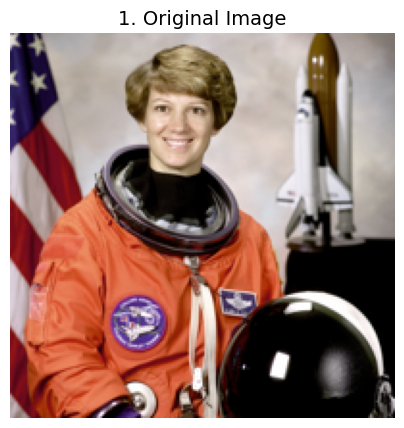

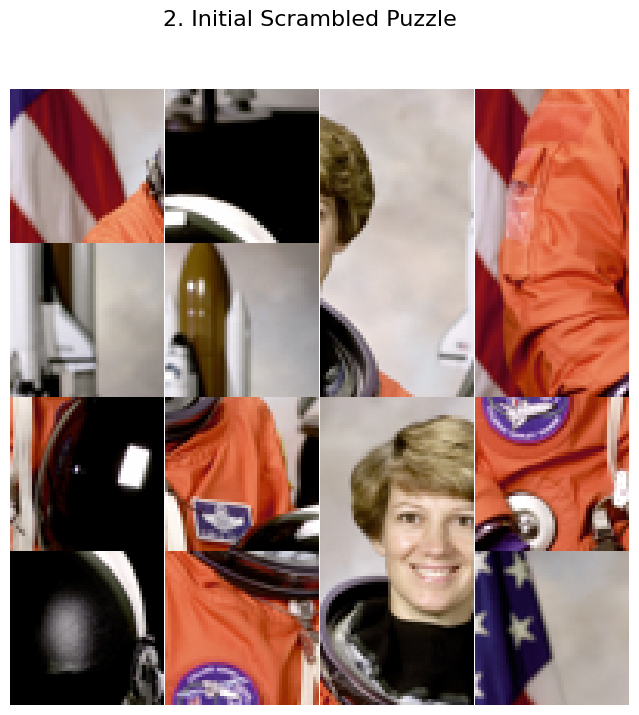

Running Evolutionary Algorithm...
Gen 0: Best Fitness 105.1660
Gen 500: Best Fitness 201.6802
Gen 1000: Best Fitness 201.6802
Gen 1500: Best Fitness 201.6802
Gen 2000: Best Fitness 201.6802
Gen 2500: Best Fitness 201.6802
Gen 3000: Best Fitness 201.6802
Gen 3500: Best Fitness 201.6802


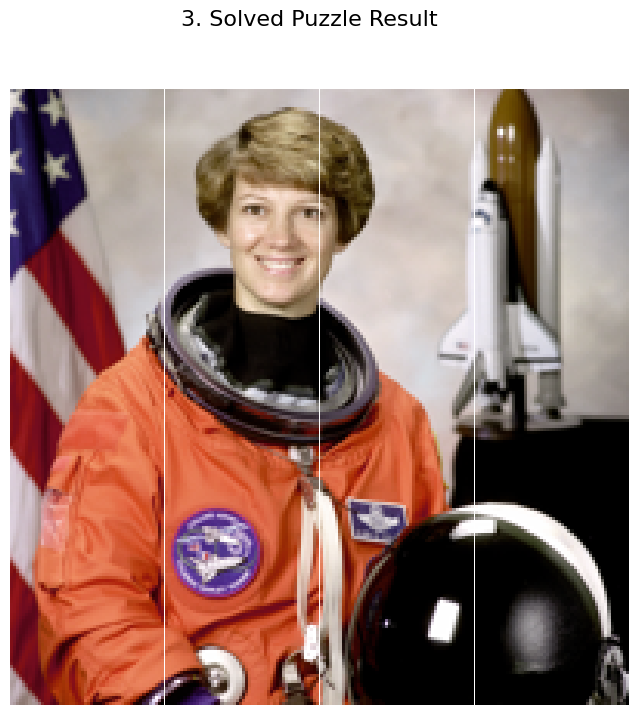

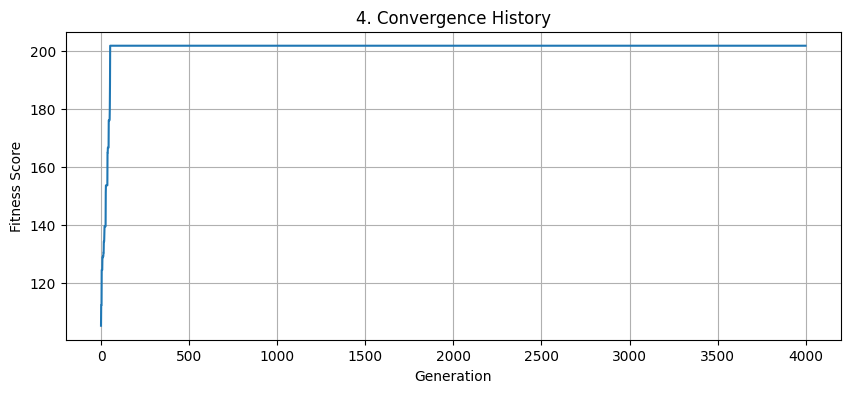

In [6]:
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title("1. Original Image", fontsize=14)
plt.axis('off')
plt.show()

scrambled_indices = list(np.random.permutation(num_pieces))
fig, axes = plt.subplots(ROWS, COLS, figsize=(8, 8))
plt.subplots_adjust(wspace=0, hspace=0)

for r in range(ROWS):
    for c in range(COLS):
        idx = r * COLS + c
        pid = scrambled_indices[idx]
        axes[r, c].imshow(display_pieces[pid])
        axes[r, c].axis('off')

plt.suptitle("2. Initial Scrambled Puzzle", fontsize=16)
plt.show()

print("Running Evolutionary Algorithm...")
best_order, history = run_evolution()

fig, axes = plt.subplots(ROWS, COLS, figsize=(8, 8))
plt.subplots_adjust(wspace=0, hspace=0)
grid_order = np.array(best_order).reshape(ROWS, COLS)

for r in range(ROWS):
    for c in range(COLS):
        pid = grid_order[r, c]
        axes[r, c].imshow(display_pieces[pid])
        axes[r, c].axis('off')

plt.suptitle("3. Solved Puzzle Result", fontsize=16)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history)
plt.title("4. Convergence History")
plt.xlabel("Generation")
plt.ylabel("Fitness Score")
plt.grid(True)
plt.show()

# Question 14: Step-Size Strategies in Gradient Descent

In this problem, we compare Batch Gradient Descent (BGD) with two different step-size selection strategies:
1.  **Backtracking Line Search (Armijo Rule)**
2.  **Adaptive Learning Rate (RMSProp)**

We use the **Rosenbrock function** as the test objective. It is defined as:
$$f(x, y) = 100(y - x^2)^2 + (1 - x)^2$$
The global minimum is at $(1, 1)$ with $f(x^*)=0$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(x):
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

def rosenbrock_grad(x):
    df_dx0 = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
    df_dx1 = 200 * (x[1] - x[0]**2)
    return np.array([df_dx0, df_dx1])

### Method 1: Gradient Descent with Backtracking Line Search

Backtracking line search ensures that we choose a step size $\alpha$ that guarantees a sufficient decrease in the function value (Armijo condition).
In each iteration, we start with a large step size and reduce it by a factor $\rho \in (0, 1)$ until the following condition is met:
$$f(x_k - \alpha \nabla f_k) \le f(x_k) - c \cdot \alpha ||\nabla f_k||^2$$

In [8]:
def gd_backtracking(start_point, max_iter=2000, alpha=1.0, rho=0.5, c=1e-4):
    path = [start_point]
    x = start_point.copy()
    
    for _ in range(max_iter):
        grad = rosenbrock_grad(x)
        if np.linalg.norm(grad) < 1e-6:
            break
            
        step_size = alpha
        while rosenbrock(x - step_size * grad) > rosenbrock(x) - c * step_size * np.dot(grad, grad):
            step_size *= rho
            
        x = x - step_size * grad
        path.append(x)
        
    return np.array(path)

### Method 2: RMSProp (Adaptive Learning Rate)

RMSProp adapts the learning rate for each parameter individually. It divides the learning rate by an exponentially decaying average of squared gradients. This helps the algorithm navigate the "flat" directions of the Rosenbrock valley faster while preventing oscillation in steep directions.

In [9]:
def gd_rmsprop(start_point, max_iter=2000, lr=0.002, beta=0.9, epsilon=1e-8):
    path = [start_point]
    x = start_point.copy()
    sq_grad_avg = np.zeros_like(x)
    
    for _ in range(max_iter):
        grad = rosenbrock_grad(x)
        if np.linalg.norm(grad) < 1e-6:
            break
            
        sq_grad_avg = beta * sq_grad_avg + (1 - beta) * grad**2
        x = x - (lr / (np.sqrt(sq_grad_avg) + epsilon)) * grad
        path.append(x)
        
    return np.array(path)

### Results & Comparison

We initialize both algorithms at $x_0 = [-1.2, 1.0]$ and visualize:
1.  **Trajectory Plot:** The path taken by each optimizer on the function contour.
2.  **Convergence Plot:** The value of $f(x)$ versus iterations (log scale).

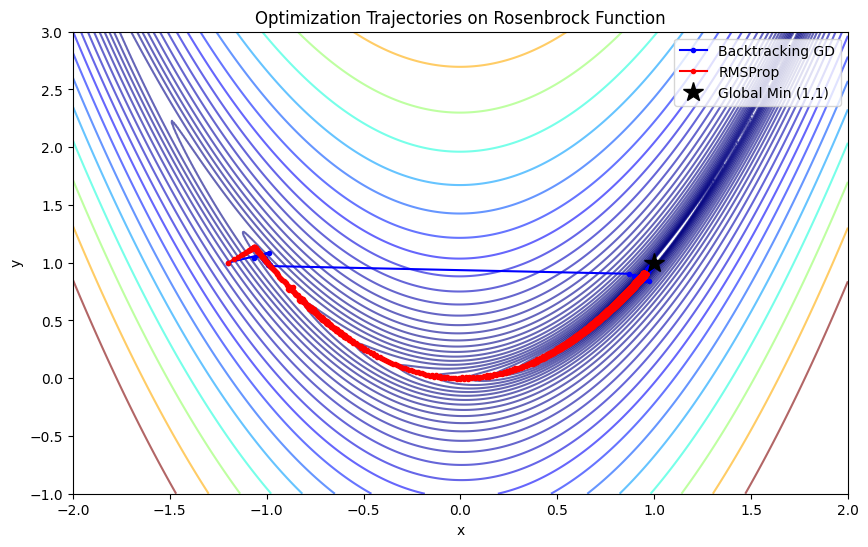

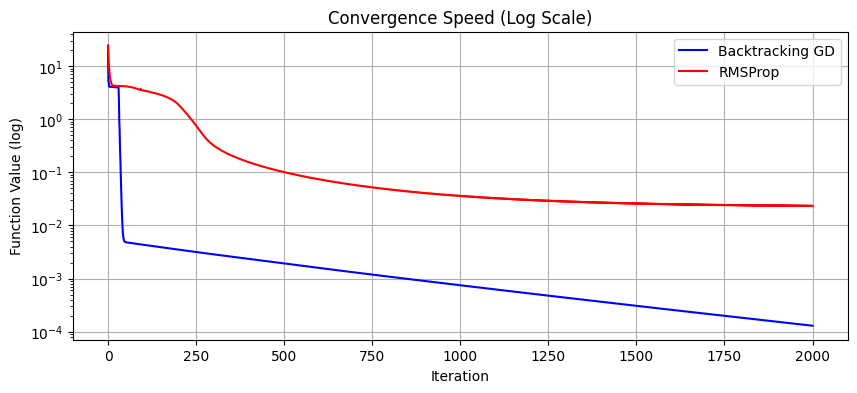

In [10]:
x0 = np.array([-1.2, 1.0])

path_bt = gd_backtracking(x0)
path_rms = gd_rmsprop(x0, lr=0.01, max_iter=2000)

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = 100 * (Y - X**2)**2 + (1 - X)**2

plt.figure(figsize=(10, 6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 30), cmap='jet', alpha=0.6)
plt.plot(path_bt[:, 0], path_bt[:, 1], 'o-', color='blue', label='Backtracking GD', markersize=3)
plt.plot(path_rms[:, 0], path_rms[:, 1], 'o-', color='red', label='RMSProp', markersize=3)
plt.plot(1, 1, 'k*', markersize=15, label='Global Min (1,1)')
plt.title('Optimization Trajectories on Rosenbrock Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

vals_bt = [rosenbrock(p) for p in path_bt]
vals_rms = [rosenbrock(p) for p in path_rms]

plt.figure(figsize=(10, 4))
plt.semilogy(vals_bt, label='Backtracking GD', color='blue')
plt.semilogy(vals_rms, label='RMSProp', color='red')
plt.title('Convergence Speed (Log Scale)')
plt.xlabel('Iteration')
plt.ylabel('Function Value (log)')
plt.legend()
plt.grid(True)
plt.show()

### Conclusion & Analysis

Based on the optimization trajectories and convergence plots, we can draw the following conclusions:

1.  **Backtracking Line Search (Blue Line):**
    * **Behavior:** It demonstrates a very aggressive initial descent (sharp drop in loss), quickly reaching the vicinity of the valley floor. This is due to its ability to take large steps when the descent condition is met.
    * **Pros:** Guarantees convergence and monotone decrease in function value. Very effective in deterministic settings.
    * **Cons:** Once inside the narrow valley (where gradients are small), the step sizes become conservative, leading to slower progress towards the exact minimum compared to the initial phase.

2.  **RMSProp (Red Line):**
    * **Behavior:** It exhibits a smoother, more consistent trajectory. By adapting the learning rate to the curvature (dividing by the moving average of squared gradients), it navigates the "banana-shaped" valley efficiently without needing explicit line search.
    * **Pros:** Handles the varying curvature of the Rosenbrock function well. It maintains steady progress even when gradients in some directions are very small.
    * **Cons:** Requires tuning of hyperparameters (learning rate $\eta$, decay rate $\beta$). In this specific deterministic run, it converged slightly slower in final precision compared to the aggressive backtracking method, but in stochastic settings (noisy gradients), it would likely outperform.

**Final Verdict:** For this specific smooth, deterministic problem, Backtracking GD provided a highly accurate solution with a rapid initial drop. However, RMSProp demonstrated its characteristic robustness in navigating complex loss landscapes with varying curvature.